In [ ]:
import os
import glob
import pandas as pd
import numpy as np
!pip install neurokit2
import neurokit2 as nk
from tqdm import tqdm
from google.colab import drive

# ==============================
# 1. MOUNT DRIVE
# ==============================
drive.mount('/content/drive')

# ==============================
# 2. PATH SETUP
# ==============================
BASE_PATH = '/content/drive/MyDrive/Research_Paper'
INPUT_DIR = os.path.join(BASE_PATH, 'd. Results/WESAD_Processed_Data')
OUTPUT_DIR = os.path.join(BASE_PATH, 'd. Results/WESAD_Extracted_Features')

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ==============================
# 3. FEATURE EXTRACTION FUNCTION
# ==============================
def extract_wesad_features(df, subject_id, ecg_rate=700, eda_rate=700, window_sec=60, overlap_sec=30):
    """
    Extract HRV + EDA features using sliding windows.
    Returns feature dataframe + debug stats.
    """

    window_len = window_sec * ecg_rate
    step_len = overlap_sec * ecg_rate

    features_list = []
    total_windows = 0
    valid_label_windows = 0
    skipped_windows = 0

    required_cols = ['ECG_Clean', 'EDA_Clean', 'Label']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"Missing required columns in {subject_id}")

    if len(df) < window_len:
        print(f"{subject_id}: Not enough samples ({len(df)}) for one full window.")
        return pd.DataFrame(), total_windows, valid_label_windows, skipped_windows

    for i in tqdm(range(0, len(df) - window_len, step_len), desc=f"{subject_id}"):

        total_windows += 1
        window = df.iloc[i : i + window_len]

        # Safe label extraction
        mode_vals = window['Label'].mode()
        if len(mode_vals) == 0:
            skipped_windows += 1
            continue

        label = mode_vals.iloc[0]

        # Only target states
        if label not in [1, 2, 3]:
            skipped_windows += 1
            continue

        valid_label_windows += 1

        try:
            # --- ECG ---
            ecg_signals, ecg_info = nk.ecg_process(
                window['ECG_Clean'],
                sampling_rate=ecg_rate
            )

            hrv_metrics = nk.hrv(
                ecg_signals,
                sampling_rate=ecg_rate
            )

            # --- EDA ---
            eda_signals, eda_info = nk.eda_process(
                window['EDA_Clean'],
                sampling_rate=eda_rate
            )

            eda_metrics = nk.eda_analyze(
                eda_signals,
                sampling_rate=eda_rate
            )

            # --- COMBINE ---
            combined = pd.concat([hrv_metrics, eda_metrics], axis=1)
            combined['label'] = label
            combined['subject'] = subject_id

            features_list.append(combined)

        except Exception as e:
            skipped_windows += 1
            print(f"Skipped window in {subject_id} ({i} to {i+window_len}): {e}")
            continue

    if len(features_list) == 0:
        return pd.DataFrame(), total_windows, valid_label_windows, skipped_windows

    final_df = pd.concat(features_list, ignore_index=True)

    return final_df, total_windows, valid_label_windows, skipped_windows


# ==============================
# 4. PROCESS ALL SUBJECTS
# ==============================
all_subjects_files = sorted(glob.glob(os.path.join(INPUT_DIR, "S*_cleaned.csv")))

if len(all_subjects_files) == 0:
    raise ValueError("No cleaned CSV files found in input directory!")

print(f"Found {len(all_subjects_files)} cleaned subject files.\n")

missing_subjects = []
summary_log = []

for file_path in all_subjects_files:

    subj_name = os.path.basename(file_path).split('_')[0]

    print(f"\n==============================")
    print(f"Processing {subj_name}")
    print(f"==============================")

    try:
        df_subj = pd.read_csv(file_path)

        print(f"{subj_name}: Total Samples = {len(df_subj)}")

        if 'Label' in df_subj.columns:
            print(f"{subj_name}: Label Distribution:")
            print(df_subj['Label'].value_counts().to_dict())

        feature_matrix, total_windows, valid_label_windows, skipped_windows = extract_wesad_features(
            df_subj,
            subj_name
        )

        summary_log.append({
            'Subject': subj_name,
            'Total_Samples': len(df_subj),
            'Total_Windows': total_windows,
            'Valid_Label_Windows': valid_label_windows,
            'Skipped_Windows': skipped_windows,
            'Features_Extracted': 0 if feature_matrix.empty else len(feature_matrix)
        })

        if feature_matrix.empty:
            print(f"⚠️ No features extracted for {subj_name}")
            missing_subjects.append(subj_name)
            continue

        save_path = os.path.join(OUTPUT_DIR, f"{subj_name}_features.csv")
        feature_matrix.to_csv(save_path, index=False)

        print(f"✅ Saved features: {save_path}")

    except Exception as e:
        print(f"❌ Error processing {subj_name}: {e}")
        missing_subjects.append(subj_name)


# ==============================
# 5. SAVE DEBUG SUMMARY
# ==============================
summary_df = pd.DataFrame(summary_log)
summary_save_path = os.path.join(OUTPUT_DIR, 'Feature_Extraction_Summary.csv')
summary_df.to_csv(summary_save_path, index=False)

print(f"\n📋 Summary log saved at:\n{summary_save_path}")


# ==============================
# 6. CONSOLIDATE MASTER FILE
# ==============================
print("\nConsolidating Master Feature Matrix...")

all_feature_files = glob.glob(os.path.join(OUTPUT_DIR, "S*_features.csv"))

if len(all_feature_files) == 0:
    print("⚠️ No feature files found!")
else:
    master_df = pd.concat(
        [pd.read_csv(f) for f in all_feature_files],
        ignore_index=True
    )

    master_path = os.path.join(BASE_PATH, "WESAD_MASTER_FEATURES.csv")
    master_df.to_csv(master_path, index=False)

    print(f"✅ Master Feature Matrix saved at:\n{master_path}")


# ==============================
# 7. FINAL REPORT
# ==============================
print("\n==============================")
print("FINAL REPORT")
print("==============================")

if len(missing_subjects) == 0:
    print("✅ Features extracted for all subjects successfully.")
else:
    print("⚠️ Subjects with no extracted features / errors:")
    print(missing_subjects)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 24.3 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 15 cleaned subject files.


Processing S10
S10: Total Samples = 3847200
S10: Label Distribution:
{0: 1589000, 1: 826000, 4: 557200, 2: 507500, 3: 260400, 7: 39900, 5: 35700, 6: 31500}


S10:   0%|          | 0/182 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S10:   2%|▏         | 4/182 [00:01<01:06,  2.69it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S10:   3%|▎         | 5/182 [00:02<01:58,  1.49it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maxi

✅ Saved features: /content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features/S10_features.csv

Processing S11
S11: Total Samples = 3663100
S11: Label Distribution:
{0: 1443400, 1: 826000, 4: 553701, 2: 476000, 3: 257600, 6: 36399, 5: 35000, 7: 35000}


S11:   0%|          | 0/173 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S11:   2%|▏         | 3/173 [00:01<01:10,  2.40it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S11:   2%|▏         | 4/173 [00:02<01:42,  1.64it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maxi

✅ Saved features: /content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features/S11_features.csv

Processing S13
S13: Total Samples = 3875900
S13: Label Distribution:
{0: 1679300, 1: 826001, 4: 556499, 2: 464800, 3: 267400, 5: 34300, 6: 33600, 7: 14000}


...

✅ Saved features: /content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features/S7_features.csv

Processing S8
S8: Total Samples = 3826200
S8: Label Distribution:
{0: 1616300, 1: 818300, 4: 557200, 2: 469000, 3: 258999, 7: 36400, 6: 35701, 5: 34300}


S8:   0%|          | 0/181 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S8:   3%|▎         | 6/181 [00:00<00:23,  7.52it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S8:   4%|▍         | 7/181 [00:01<00:48,  3.57it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum

✅ Saved features: /content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features/S8_features.csv

Processing S9
S9: Total Samples = 3656100
S9: Label Distribution:
{0: 1435700, 1: 826000, 4: 555100, 2: 451500, 3: 260400, 6: 43400, 5: 42000, 7: 42000}


S9:   0%|          | 0/173 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S9:   2%|▏         | 3/173 [00:01<01:07,  2.53it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
S9:   2%|▏         | 4/173 [00:02<01:54,  1.47it/s]/usr/local/lib/python3.12/dist-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum

✅ Saved features: /content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features/S9_features.csv

📋 Summary log saved at:
/content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features/Feature_Extraction_Summary.csv

Consolidating Master Feature Matrix...
✅ Master Feature Matrix saved at:
/content/drive/MyDrive/Research_Paper/WESAD_MASTER_FEATURES.csv

FINAL REPORT
✅ Features extracted for all subjects successfully.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 15 subject files.
Combined Data Shape: (1105, 103)
Cleaned Data Shape: (1105, 94)


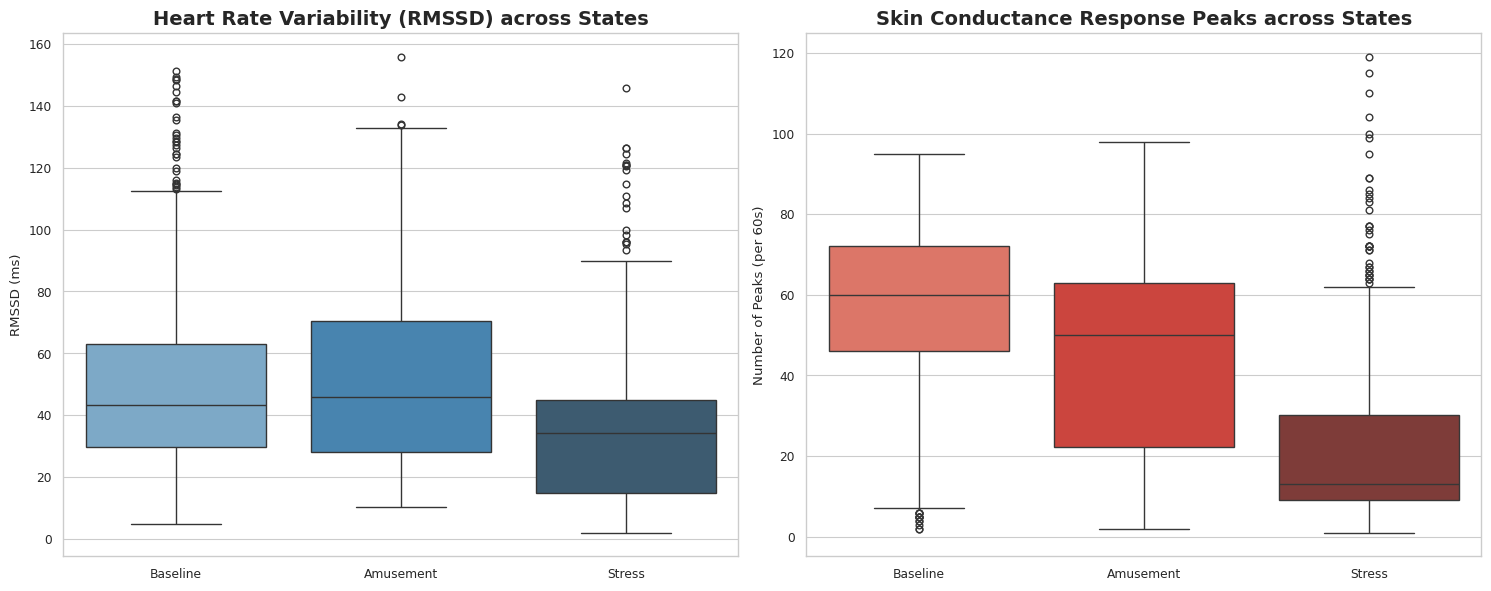


✅ Graph saved successfully at:
/content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features/Physio_Trends.png


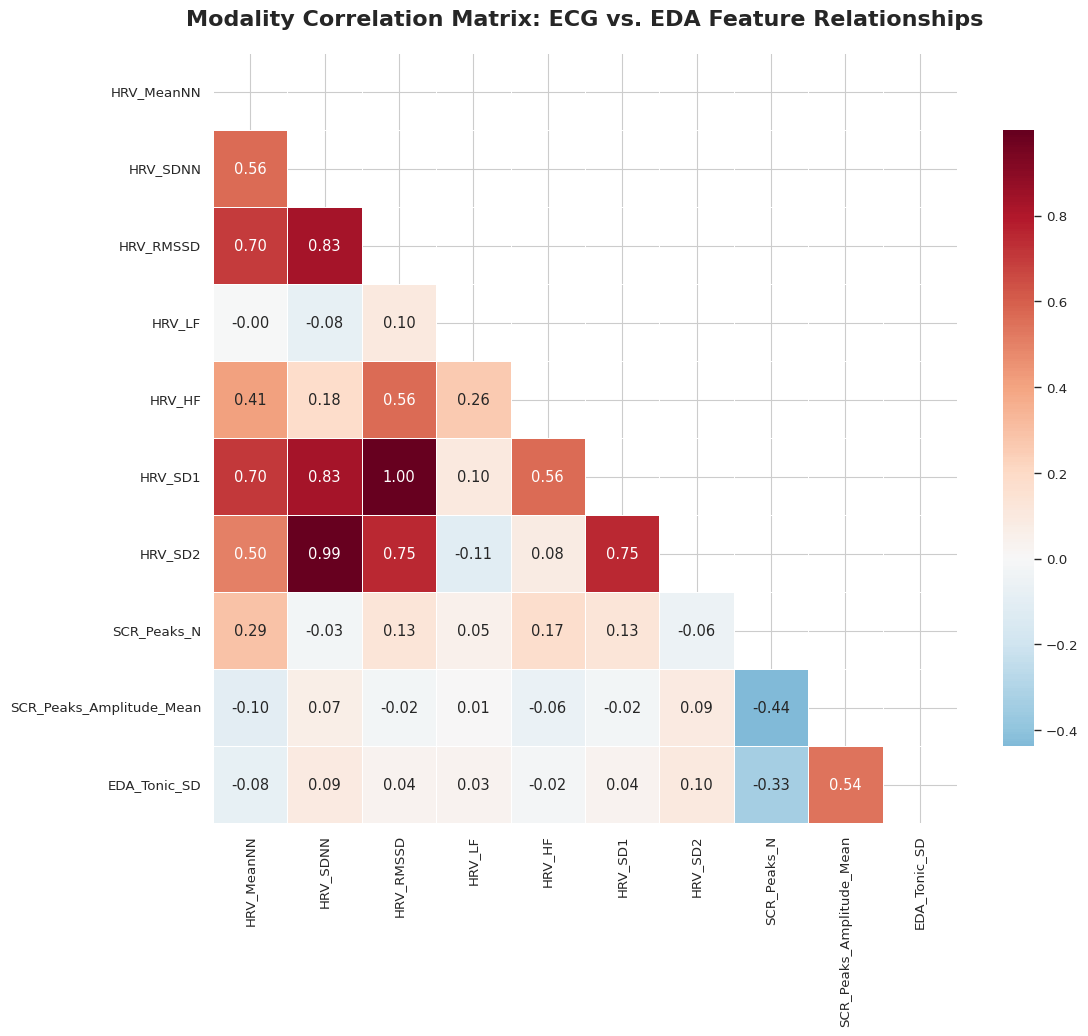


✅ Graph saved successfully at:
/content/drive/MyDrive/Research_Paper/Modality_Correlation_Heatmap.png


In [ ]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 0. MOUNT DRIVE (only in Colab)
# ==============================
from google.colab import drive
drive.mount('/content/drive')

# ==============================
# 1. SET PATH
# ==============================
FEATURES_DIR = '/content/drive/MyDrive/Research_Paper/d. Results/WESAD_Extracted_Features'

# ==============================
# 2. LOAD ALL SUBJECT CSV FILES
# ==============================
all_files = glob.glob(os.path.join(FEATURES_DIR, "S*_features.csv"))

if len(all_files) == 0:
    raise ValueError("No feature CSV files found!")

print(f"Found {len(all_files)} subject files.")

# Combine all files
df_master = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

print("Combined Data Shape:", df_master.shape)

# ==============================
# 3. CLEAN DATA
# ==============================

# Remove columns that are completely NaN
df_master = df_master.dropna(axis=1, how='all')

# Check required columns exist
required_cols = ['HRV_RMSSD', 'SCR_Peaks_N', 'label']
for col in required_cols:
    if col not in df_master.columns:
        raise ValueError(f"Missing required column: {col}")

# ==============================
# 4. MAP LABELS TO CONDITIONS
# ==============================
state_map = {
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement'
}

df_master['Condition'] = df_master['label'].map(state_map)

# Remove rows with missing important values
df_master = df_master.dropna(subset=['HRV_RMSSD', 'SCR_Peaks_N', 'Condition'])

print("Cleaned Data Shape:", df_master.shape)

# ==============================
# 5. SET STYLE (RESEARCH PAPER)
# ==============================
sns.set_theme(style="whitegrid", context="paper")

# ==============================
# 6. CREATE PLOTS
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ECG Plot (HRV)
sns.boxplot(
    x='Condition',
    y='HRV_RMSSD',
    hue='Condition',
    data=df_master,
    ax=axes[0],
    palette='Blues_d',
    legend=False
)
axes[0].set_title('Heart Rate Variability (RMSSD) across States', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSSD (ms)')
axes[0].set_xlabel('')

# EDA Plot (SCR Peaks)
sns.boxplot(
    x='Condition',
    y='SCR_Peaks_N',
    hue='Condition',
    data=df_master,
    ax=axes[1],
    palette='Reds_d',
    legend=False
)
axes[1].set_title('Skin Conductance Response Peaks across States', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Peaks (per 60s)')
axes[1].set_xlabel('')

# ==============================
# 7. FINAL TOUCH
# ==============================
plt.tight_layout()

# ==============================
# 8. SAVE IMAGE (ERROR-FREE)
# ==============================
save_path = os.path.join(FEATURES_DIR, 'Physio_Trends.png')

# If a folder with same name exists, remove it
if os.path.isdir(save_path):
    import shutil
    shutil.rmtree(save_path)

plt.savefig(save_path, dpi=300)

# ==============================
# 9. DISPLAY
# ==============================
plt.show()

print(f"\n✅ Graph saved successfully at:\n{save_path}")

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Select key features to avoid a cluttered heatmap
# We pick representative features from both ECG (HRV) and EDA
hrv_features = ['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_LF', 'HRV_HF', 'HRV_SD1', 'HRV_SD2']
eda_features = [col for col in df_master.columns if 'SCR_Peaks' in col or 'SCR_Amplitude' in col or 'EDA_Tonic' in col]

# Combine the selected columns
selected_columns = hrv_features + eda_features
correlation_matrix = df_master[selected_columns].corr()

# 2. Set up the figure
plt.figure(figsize=(12, 10))
sns.set_context("paper", font_scale=1.1)

# Generate a mask for the upper triangle (optional, makes it cleaner)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# 3. Create Heatmap
# 'RdBu_r' is the standard academic color map for correlations
heatmap = sns.heatmap(correlation_matrix,
                      mask=mask,
                      annot=True,
                      fmt=".2f",
                      cmap='RdBu_r',
                      center=0,
                      linewidths=.5,
                      cbar_kws={"shrink": .8})

plt.title('Modality Correlation Matrix: ECG vs. EDA Feature Relationships',
          fontsize=16, fontweight='bold', pad=20)

# 4. Save the result
save_path = os.path.join(BASE_PATH, "Modality_Correlation_Heatmap.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

# 5. Confirmation
print(f"\n✅ Graph saved successfully at:\n{save_path}")

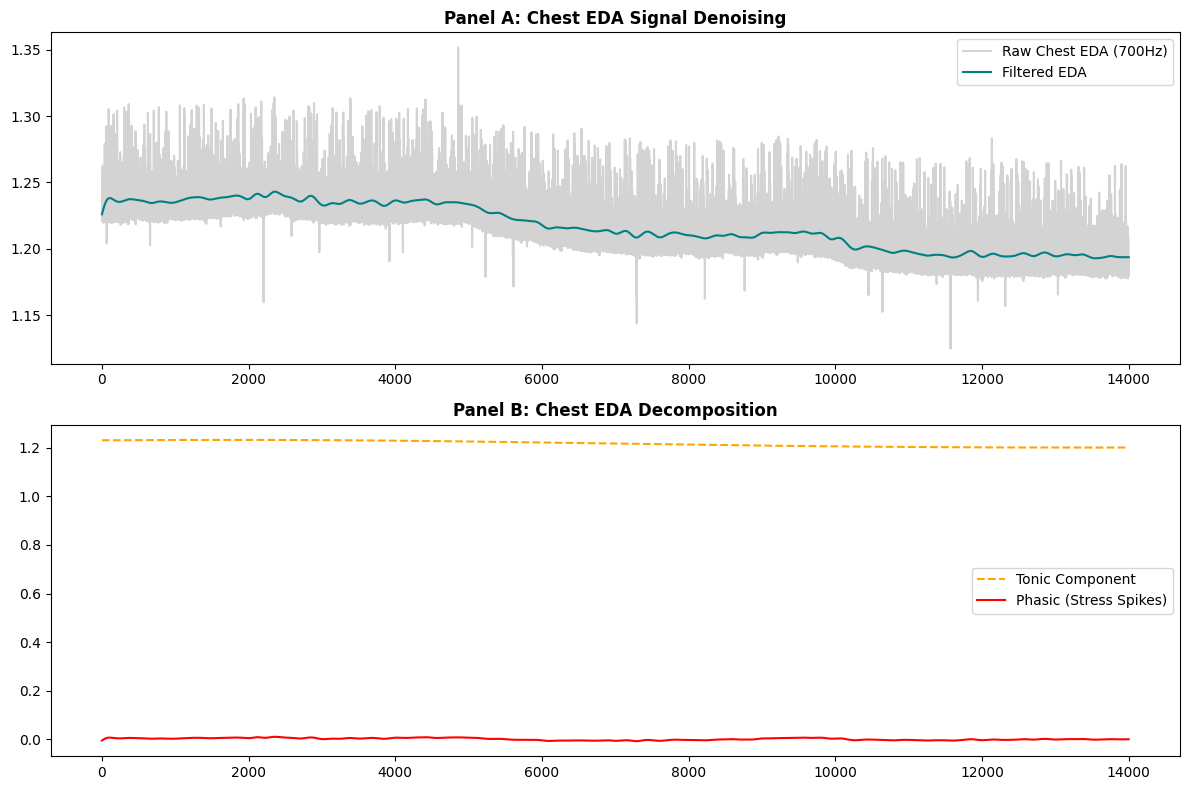

NameError: name 'df_final' is not defined

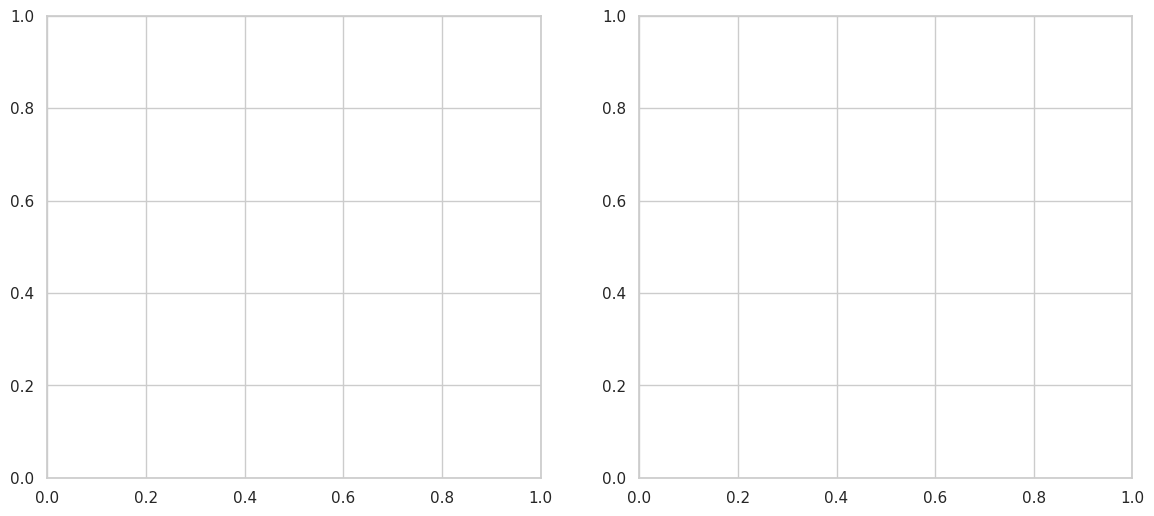

In [ ]:
import neurokit2 as nk
import matplotlib.pyplot as plt
import pickle
import numpy as np

# 1. Load the subject
with open('/content/drive/MyDrive/Research_Paper/b._Dataset/WESAD_Dataset/WESAD/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# 2. Extract CHEST EDA (700 Hz)
# Note: In WESAD chest data, EDA is usually the 3rd column or labeled 'EDA'
eda_chest = data['signal']['chest']['EDA'].flatten()
labels = data['label']

# 3. Find Stress segment (Label 2)
# Since everything is 700Hz, no division is needed!
stress_indices = np.where(labels == 2)[0]
start_idx = stress_indices[10000] # Start 10k samples into the stress period
eda_segment = eda_chest[start_idx : start_idx + 14000] # 20 seconds of data (20 * 700)

# 4. Process with NeuroKit2 (Crucial: sampling_rate=700)
signals, info = nk.eda_process(eda_segment, sampling_rate=700)

# 5. Plotting
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(signals["EDA_Raw"], color="lightgray", label="Raw Chest EDA (700Hz)")
plt.plot(signals["EDA_Clean"], color="teal", label="Filtered EDA", linewidth=1.5)
plt.title("Panel A: Chest EDA Signal Denoising", fontweight='bold')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(signals["EDA_Tonic"], color="orange", label="Tonic Component", linestyle='--')
plt.plot(signals["EDA_Phasic"], color="red", label="Phasic (Stress Spikes)")
plt.title("Panel B: Chest EDA Decomposition", fontweight='bold')
plt.legend()

plt.tight_layout()
plt.show()

import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Boxplot for ECG Feature (RMSSD)
sns.boxplot(ax=axes[0], x='label', y='HRV_RMSSD', data=df_final, palette="muted")
axes[0].set_title('Heart Rate Variability (RMSSD)', fontweight='bold')
axes[0].set_xticklabels(['Baseline', 'Stress', 'Amusement'])
axes[0].set_ylabel('ms')

# 2. Boxplot for EDA Feature (Tonic Level)
sns.boxplot(ax=axes[1], x='label', y='EDA_Tonic_Mean', data=df_final, palette="muted")
axes[1].set_title('Skin Conductance Level (Tonic)', fontweight='bold')
axes[1].set_xticklabels(['Baseline', 'Stress', 'Amusement'])
axes[1].set_ylabel('μS')

plt.suptitle('Statistical Distribution of Physiological Features Across States', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save for the paper
plt.savefig("/content/drive/MyDrive/Research_Paper/d. Results/Feature_Boxplots.png", dpi=300)
plt.show()